In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

import ast
pd.set_option('display.max_columns', None)
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import seaborn as sns
import warnings # To suppress some warnings
import plotly.graph_objects as go
import plotly.express as px

# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Add the classifiers to the imports here:
# ANSWER STARTING HERE

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import GradientBoostingClassifier

import hashlib
from sklearn.preprocessing import MinMaxScaler

In [55]:
df = pd.read_csv("diabetes_dataset.csv")

df = df[df['ldl_cholesterol'] > 50]

df = df[df['insulin_level'] > 2]



X = df[['ldl_cholesterol','insulin_level','hba1c','waist_to_hip_ratio']]
Y = df[['diabetes_stage']]

Y['diabetes_num'] = -1
Y['diabetes_num'] = Y['diabetes_stage'].apply(lambda x: 0 if x == 'No Diabetes' else (1 if x == 'Pre-Diabetes' else (2 if x == 'Type 1' else (3 if x == 'Type 2' else (4 if x == 'Gestational' else -1)))))

print(list(Y['diabetes_num']))
print(list(Y['diabetes_stage']))

# no missing diabetes stage labels
print(Y[Y['diabetes_num'] == -1].sum())



[3, 3, 3, 3, 1, 1, 3, 3, 0, 3, 3, 3, 1, 1, 3, 3, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 3, 1, 3, 1, 3, 3, 1, 1, 1, 1, 3, 3, 3, 1, 1, 3, 3, 3, 1, 3, 3, 3, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 3, 3, 3, 1, 3, 3, 4, 1, 3, 3, 1, 1, 0, 0, 3, 3, 3, 3, 3, 1, 3, 3, 0, 3, 1, 3, 3, 1, 1, 3, 0, 1, 3, 3, 3, 1, 1, 1, 1, 3, 1, 3, 3, 3, 0, 1, 3, 3, 3, 3, 1, 3, 0, 3, 3, 3, 1, 0, 3, 1, 3, 3, 1, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 1, 3, 3, 3, 3, 3, 3, 0, 1, 1, 2, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 1, 3, 3, 0, 1, 3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 0, 3, 1, 3, 1, 3, 0, 3, 3, 1, 3, 1, 3, 1, 3, 1, 1, 3, 3, 0, 1, 1, 3, 3, 3, 1, 3, 3, 1, 3, 1, 0, 3, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 0, 0, 3, 3, 3, 0, 3, 1, 1, 3, 0, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 1, 3, 3, 3, 1, 3, 1, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 1, 0, 3, 3, 1, 1, 0, 0, 1, 1, 3, 1, 1, 3, 3, 3, 3, 3, 1, 3, 1, 0, 3, 1, 0, 3, 0, 1, 1, 1, 3, 3, 

In [56]:
seed = 67
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, Y['diabetes_num'], test_size=test_size, random_state=seed)

In [57]:
scaler = StandardScaler().fit(X)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
models = {
    'Logistic Regression': LogisticRegression(random_state=seed,max_iter=1000),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=seed),
    'Decision Tree'    : DecisionTreeClassifier(random_state=seed),
    'Random Forest'    : RandomForestClassifier(random_state=seed),
    'KNN'              : KNeighborsClassifier()
}

In [59]:
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)

for model_name, model in models.items():
    np.random.seed(42)
    print(f"Model: {model_name}")

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf)
    print(f"Cross-validated Accuracy: {cv_scores.mean()} (+/- {cv_scores.std()})")

Model: Logistic Regression
Cross-validated Accuracy: 0.7938280897185007 (+/- 0.0028599158493179044)
Model: Gradient Boosting


KeyboardInterrupt: 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer


pipeline_list = {}

for model_name, model in models.items():
    param_grid = {}
    if model_name == 'Logistic Regression':
        param_grid = {'model__max_iter': [1000, 2000, 3000],
                      'model__C': [0.01, 0.1, 1, 10]}
    elif model_name == 'Gradient Boosting':
        param_grid = {'model__n_estimators': [100, 200],
                    'model__learning_rate': [0.01, 0.1, 0.2],
                    'model__max_depth': [3, 5, 7]}
    elif model_name == 'Decision Tree':
        param_grid = {'model__max_depth': [None, 10, 20, 30],
                    'model__min_samples_split': [2, 5, 10]}
    elif model_name == 'Random Forest':
        param_grid = {'model__n_estimators': [100, 200],
                    'model__max_depth': [None, 10, 20, 30],
                    'model__min_samples_split': [2, 5, 10]}
    else:
        continue
    
    pipeline = Pipeline(steps=[('scaler', StandardScaler()), ('model', model)])
    grid_search = GridSearchCV(pipeline, param_grid, cv=5,
                            scoring='recall_macro', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    models[model_name] = grid_search.best_estimator_

    pipeline_list[model_name] = grid_search

In [72]:
# Train each model using the training data
for model_name, model in models.items():
    # Set random seed for reproducibility
    np.random.seed(seed)

    model.fit(X_train_scaled,y_train)

# Evaluate the performance of each model
for model_name, model in models.items():
    np.random.seed(seed)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test,y_pred)
    print(f"Accuracy of {model_name}: {accuracy:.3f}") # Your accuracy table header here
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2', 'Gestational']))

Accuracy of Logistic Regression: 0.790
              precision    recall  f1-score   support

 No Diabetes       0.63      0.46      0.53      1197
Pre-Diabetes       0.69      0.68      0.68      5231
      Type 1       0.00      0.00      0.00        21
      Type 2       0.85      0.89      0.87     10118
 Gestational       0.00      0.00      0.00        41

    accuracy                           0.79     16608
   macro avg       0.43      0.41      0.42     16608
weighted avg       0.78      0.79      0.79     16608

Accuracy of Gradient Boosting: 0.859
              precision    recall  f1-score   support

 No Diabetes       0.53      0.79      0.64      1197
Pre-Diabetes       0.77      0.90      0.83      5231
      Type 1       0.00      0.00      0.00        21
      Type 2       1.00      0.85      0.92     10118
 Gestational       0.00      0.00      0.00        41

    accuracy                           0.86     16608
   macro avg       0.46      0.51      0.48     16608
w

/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Accuracy of Random Forest: 0.862
              precision    recall  f1-score   support

 No Diabetes       0.54      0.82      0.65      1197
Pre-Diabetes       0.77      0.90      0.83      5231
      Type 1       0.00      0.00      0.00        21
      Type 2       1.00      0.85      0.92     10118
 Gestational       0.00      0.00      0.00        41

    accuracy                           0.86     16608
   macro avg       0.46      0.51      0.48     16608
weighted avg       0.89      0.86      0.87     16608

Accuracy of KNN: 0.827
              precision    recall  f1-score   support

 No Diabetes       0.52      0.67      0.59      1197
Pre-Diabetes       0.73      0.81      0.77      5231
      Type 1       0.00      0.00      0.00        21
      Type 2       0.94      0.86      0.90     10118
 Gestational       0.00      0.00      0.00        41

    accuracy                           0.83     16608
   macro avg       0.44      0.47      0.45     16608
weighted avg       0.

/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Feature Importances:
                           0         1         2
hba1c               0.984569  0.977800  0.964122
waist_to_hip_ratio  0.008051  0.004510  0.008648
insulin_level       0.004720  0.011039  0.015298
ldl_cholesterol     0.002660  0.006651  0.011932
Index(['ldl_cholesterol', 'insulin_level', 'hba1c', 'waist_to_hip_ratio'], dtype='str')


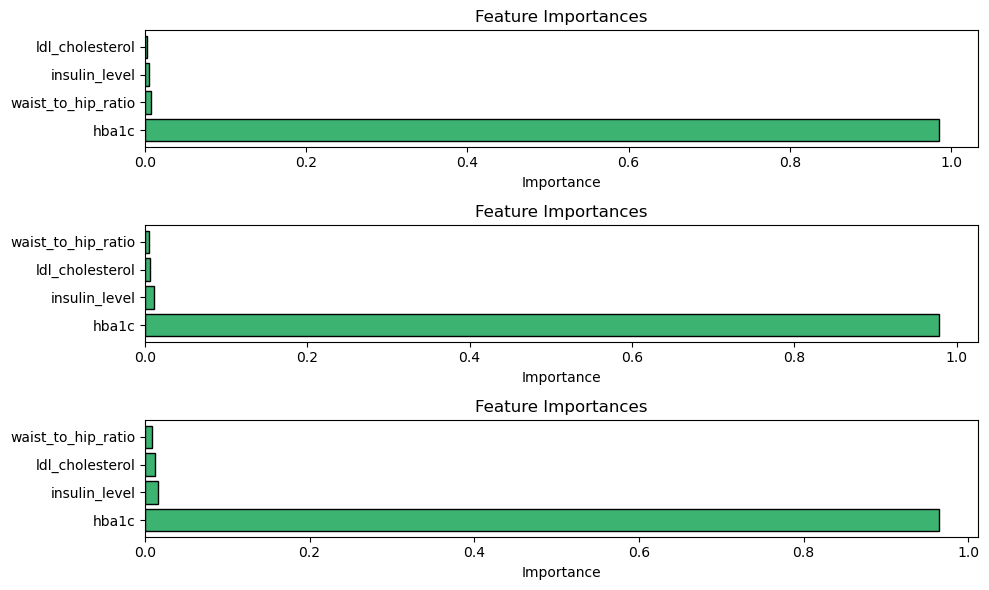

In [105]:
# Extract the feature importances from the most accurate model
importances1 = models['Gradient Boosting'][1].feature_importances_
importances2 = models['Decision Tree'][1].feature_importances_
importances3 = models['Random Forest'][1].feature_importances_


# Creating a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({0:importances1,1:importances2,2:importances3},index=X.columns).sort_values(by=[0], ascending=False)
# Displaying feature importances
print("Feature Importances:")
print(feature_importance_df[:4])
print(X.columns)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))
axes = axes.flatten()  # Make it easier to index
feature_list = [importances1, importances2, importances3]

for i, feature in enumerate(feature_list) :
    ax = axes[i]

    feature_importance = pd.Series(feature, index = X.columns).sort_values(ascending=False)
    ax.barh(feature_importance .index, feature_importance.values, color='mediumseagreen', edgecolor='black')
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importances')

plt.tight_layout()
plt.show() 